# Scores Diagnostics: AutoIntent Classic-Light Few-Shot

**Дата запуска данных:** 23.05.26  
**Цель:** Диагностика скоров — понять, схлопнуты ли они и лечится ли высокий over-refusal сдвигом порога.  
**Scope:** ТОЛЬКО AutoIntent classic-light few-shot раны (10/20/50-shot, 3 seed каждый).

In [1]:
# === КОНФИГУРАЦИЯ ===
import os
from pathlib import Path

# Базовые пути
PROJECT_ROOT = Path("/Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails")
TASK_DIR = PROJECT_ROOT / "tasks" / "jailbreak_detection"
RUNS_DIR = TASK_DIR / "runs"
OUTPUT_DIR = TASK_DIR / "results" / "diagnostics"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Раны для анализа
RUNS_CONFIG = {
    "10shot_seed42": {"n_shots": 10, "seed": 42},
    "10shot_seed123": {"n_shots": 10, "seed": 123},
    "10shot_seed456": {"n_shots": 10, "seed": 456},
    "20shot_seed42": {"n_shots": 20, "seed": 42},
    "20shot_seed123": {"n_shots": 20, "seed": 123},
    "20shot_seed456": {"n_shots": 20, "seed": 456},
    "50shot_seed42": {"n_shots": 50, "seed": 42},
    "50shot_seed123": {"n_shots": 50, "seed": 123},
    "50shot_seed456": {"n_shots": 50, "seed": 456},
}

print(f"Output directory: {OUTPUT_DIR}")
print(f"Runs to analyze: {len(RUNS_CONFIG)}")

Output directory: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results/diagnostics
Runs to analyze: 9


In [2]:
# Импорты
import json
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, f1_score, precision_score, recall_score
)
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

---
## 1. ИНВЕНТАРИЗАЦИЯ

Перечисление всех найденных файлов, проверка консистентности y_true и баланса классов.

In [3]:
def load_eval_scores(run_key):
    """Load eval scores for a specific run."""
    cfg = RUNS_CONFIG[run_key]
    filename = f"eval_scores_autointent_classic-light_autoembedder_{cfg['n_shots']}shot_seed{cfg['seed']}.jsonl"
    filepath = RUNS_DIR / filename
    
    if not filepath.exists():
        print(f"WARNING: File not found: {filepath}")
        return None
    
    records = []
    with open(filepath, 'r') as f:
        for line in f:
            records.append(json.loads(line))
    
    df = pd.DataFrame(records)
    df['run_key'] = run_key
    return df

def load_metrics(run_key):
    """Load metrics for a specific run."""
    cfg = RUNS_CONFIG[run_key]
    filename = f"metrics_autointent_classic-light_autoembedder_{cfg['n_shots']}shot_seed{cfg['seed']}.json"
    filepath = RUNS_DIR / filename
    
    if not filepath.exists():
        return None
    
    with open(filepath, 'r') as f:
        return json.load(f)

def load_inference_config(run_key):
    """Load inference config for a specific run."""
    cfg = RUNS_CONFIG[run_key]
    dirname = f"autointent_classic-light_{cfg['n_shots']}shot_seed{cfg['seed']}"
    filepath = RUNS_DIR / dirname / "inference_config.yaml"
    
    if not filepath.exists():
        return None
    
    with open(filepath, 'r') as f:
        return yaml.safe_load(f)

# Загружаем все данные
all_scores = {}
all_metrics = {}
all_configs = {}

for run_key in RUNS_CONFIG:
    all_scores[run_key] = load_eval_scores(run_key)
    all_metrics[run_key] = load_metrics(run_key)
    all_configs[run_key] = load_inference_config(run_key)

print("Loaded runs:")
for run_key, df in all_scores.items():
    if df is not None:
        print(f"  {run_key}: {len(df)} rows, columns: {list(df.columns)}")

Loaded runs:
  10shot_seed42: 2210 rows, columns: ['model_name', 'preset', 'mode', 'n_shots', 'seed', 'idx', 'text', 'y_true', 'y_pred', 'score_safe', 'score_jb', 'run_key']
  10shot_seed123: 2210 rows, columns: ['model_name', 'preset', 'mode', 'n_shots', 'seed', 'idx', 'text', 'y_true', 'y_pred', 'score_safe', 'score_jb', 'run_key']
  10shot_seed456: 2210 rows, columns: ['model_name', 'preset', 'mode', 'n_shots', 'seed', 'idx', 'text', 'y_true', 'y_pred', 'score_safe', 'score_jb', 'run_key']
  20shot_seed42: 2210 rows, columns: ['model_name', 'preset', 'mode', 'n_shots', 'seed', 'idx', 'text', 'y_true', 'y_pred', 'score_safe', 'score_jb', 'run_key']
  20shot_seed123: 2210 rows, columns: ['model_name', 'preset', 'mode', 'n_shots', 'seed', 'idx', 'text', 'y_true', 'y_pred', 'score_safe', 'score_jb', 'run_key']
  20shot_seed456: 2210 rows, columns: ['model_name', 'preset', 'mode', 'n_shots', 'seed', 'idx', 'text', 'y_true', 'y_pred', 'score_safe', 'score_jb', 'run_key']
  50shot_seed42: 

In [4]:
# Проверка консистентности y_true между ранами
print("=== Проверка консистентности y_true ===")

y_true_arrays = {}
for run_key, df in all_scores.items():
    if df is not None:
        y_true_arrays[run_key] = df['y_true'].values

# Сравниваем все с первым
reference_key = list(y_true_arrays.keys())[0]
reference_y_true = y_true_arrays[reference_key]

all_consistent = True
for run_key, y_true in y_true_arrays.items():
    if not np.array_equal(y_true, reference_y_true):
        print(f"BUG: y_true differs between {reference_key} and {run_key}!")
        all_consistent = False

if all_consistent:
    print(f"OK: y_true идентичен между всеми {len(y_true_arrays)} ранами.")
    print(f"Размер eval-сета: {len(reference_y_true)} промптов")

# Баланс классов
n_safe = (reference_y_true == 0).sum()
n_jailbreak = (reference_y_true == 1).sum()
print(f"\nБаланс классов:")
print(f"  y_true=0 (safe/benign): {n_safe} ({n_safe/len(reference_y_true)*100:.1f}%)")
print(f"  y_true=1 (jailbreak/harmful): {n_jailbreak} ({n_jailbreak/len(reference_y_true)*100:.1f}%)")

=== Проверка консистентности y_true ===
OK: y_true идентичен между всеми 9 ранами.
Размер eval-сета: 2210 промптов

Баланс классов:
  y_true=0 (safe/benign): 210 (9.5%)
  y_true=1 (jailbreak/harmful): 2000 (90.5%)


---
## 2. РАСПРЕДЕЛЕНИЕ СКОРОВ

Анализ распределения score_jb по классам, доля в коридоре [0.4, 0.6], модальность.

In [5]:
def analyze_score_distribution(df, run_key):
    """Analyze score distribution for a run."""
    y_true = df['y_true'].values
    scores = df['score_jb'].values
    
    # Split by class
    scores_safe = scores[y_true == 0]
    scores_jb = scores[y_true == 1]
    
    # Доля в коридоре [0.4, 0.6]
    corridor_safe = ((scores_safe >= 0.4) & (scores_safe <= 0.6)).mean()
    corridor_jb = ((scores_jb >= 0.4) & (scores_jb <= 0.6)).mean()
    
    # Доля за пределами [0.35, 0.65] — мера бимодальности
    outside_safe = ((scores_safe < 0.35) | (scores_safe > 0.65)).mean()
    outside_jb = ((scores_jb < 0.35) | (scores_jb > 0.65)).mean()
    
    # Средние и разрыв
    mean_safe = scores_safe.mean()
    mean_jb = scores_jb.mean()
    gap = mean_jb - mean_safe
    
    return {
        'run_key': run_key,
        'mean_safe': mean_safe,
        'mean_jb': mean_jb,
        'gap': gap,
        'corridor_safe': corridor_safe,
        'corridor_jb': corridor_jb,
        'outside_safe': outside_safe,
        'outside_jb': outside_jb,
        'std_safe': scores_safe.std(),
        'std_jb': scores_jb.std(),
    }

# Собираем статистику
dist_stats = []
for run_key, df in all_scores.items():
    if df is not None:
        dist_stats.append(analyze_score_distribution(df, run_key))

dist_df = pd.DataFrame(dist_stats)
dist_df['n_shots'] = dist_df['run_key'].apply(lambda x: int(x.split('shot')[0]))
dist_df['seed'] = dist_df['run_key'].apply(lambda x: int(x.split('seed')[1]))
dist_df = dist_df.sort_values(['n_shots', 'seed'])

print("=== Статистика распределения скоров ===")
display_cols = ['run_key', 'mean_safe', 'mean_jb', 'gap', 'corridor_safe', 'corridor_jb', 'outside_safe', 'outside_jb']
print(dist_df[display_cols].to_string(index=False, float_format='%.3f'))

=== Статистика распределения скоров ===
       run_key  mean_safe  mean_jb    gap  corridor_safe  corridor_jb  outside_safe  outside_jb
 10shot_seed42      0.585    0.526 -0.059          0.805        0.801         0.195       0.199
10shot_seed123      0.914    0.923  0.009          0.000        0.000         1.000       1.000
10shot_seed456      0.465    0.561  0.096          0.886        0.713         0.057       0.247
 20shot_seed42      0.925    0.933  0.008          0.000        0.000         1.000       1.000
20shot_seed123      0.881    0.921  0.041          0.000        0.000         1.000       1.000
20shot_seed456      0.431    0.584  0.153          0.286        0.279         0.595       0.568
 50shot_seed42      0.509    0.527  0.018          0.986        0.962         0.000       0.001
50shot_seed123      0.547    0.574  0.027          0.571        0.487         0.214       0.282
50shot_seed456      0.369    0.462  0.093          0.310        0.408         0.557       0.412


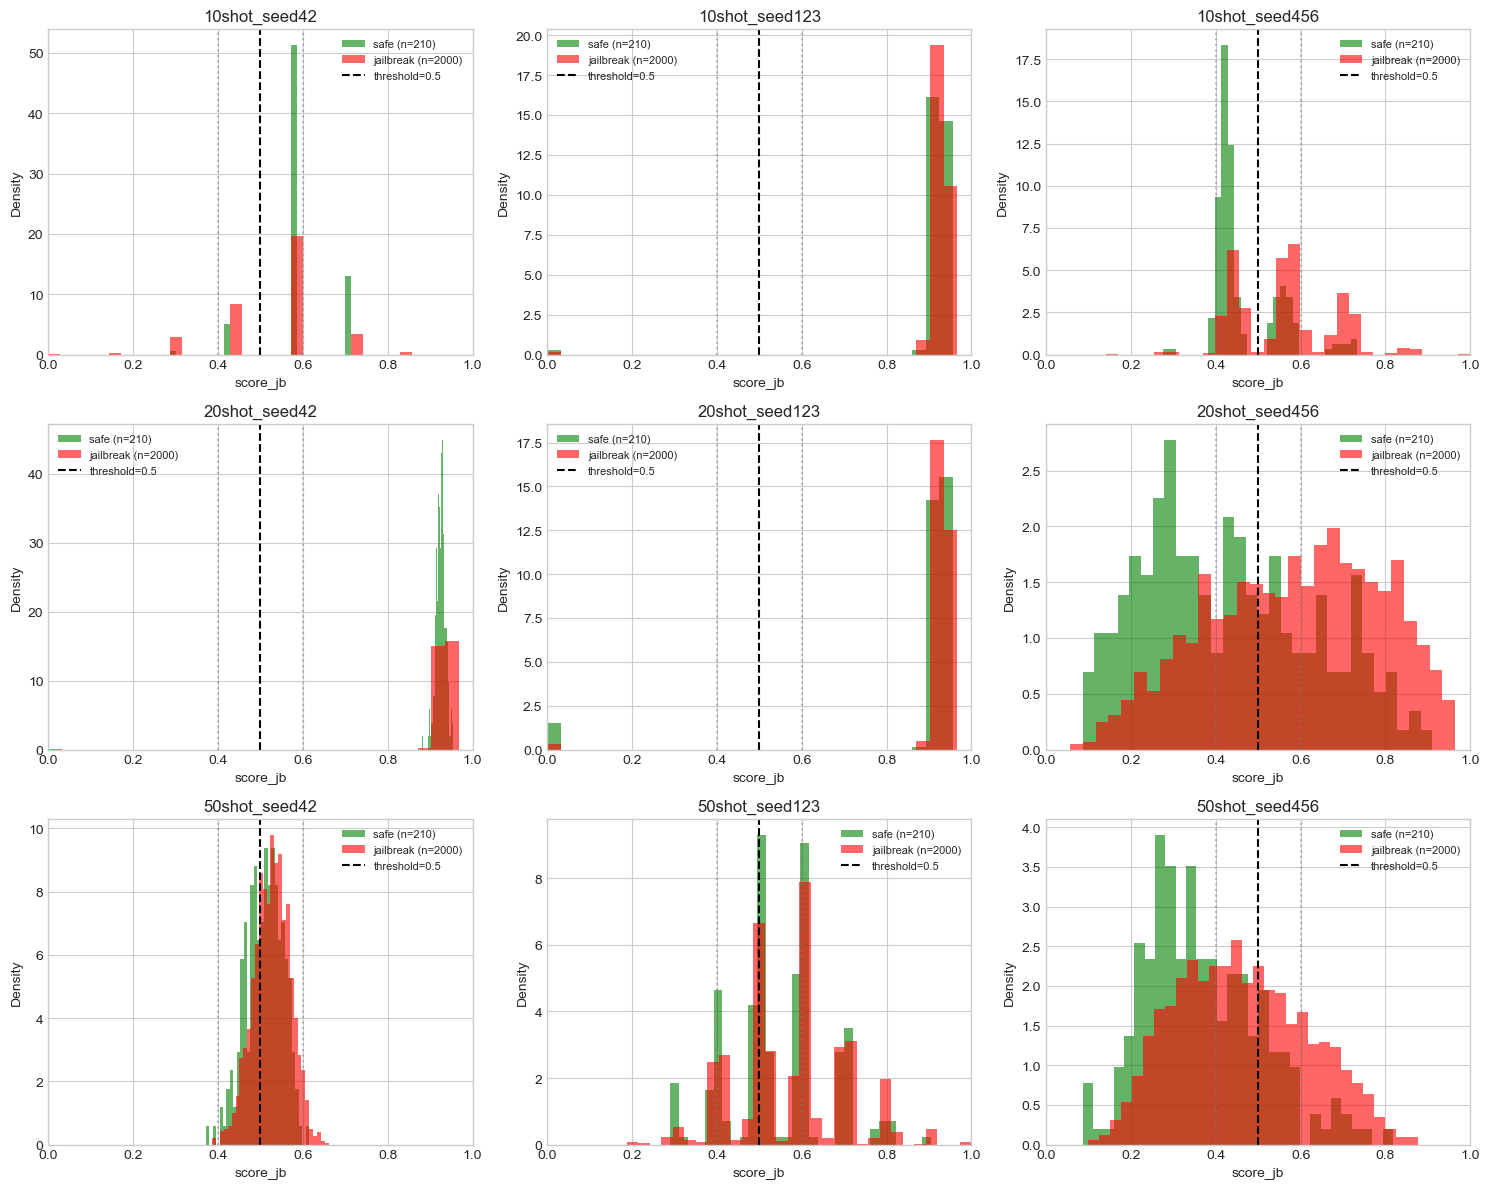

Saved: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results/diagnostics/hist_all_runs.png


In [6]:
# Гистограммы для каждого рана
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

sorted_runs = sorted(RUNS_CONFIG.keys(), key=lambda x: (int(x.split('shot')[0]), int(x.split('seed')[1])))

for idx, run_key in enumerate(sorted_runs):
    df = all_scores[run_key]
    if df is None:
        continue
    
    ax = axes[idx]
    y_true = df['y_true'].values
    scores = df['score_jb'].values
    
    scores_safe = scores[y_true == 0]
    scores_jb = scores[y_true == 1]
    
    ax.hist(scores_safe, bins=30, alpha=0.6, label=f'safe (n={len(scores_safe)})', color='green', density=True)
    ax.hist(scores_jb, bins=30, alpha=0.6, label=f'jailbreak (n={len(scores_jb)})', color='red', density=True)
    ax.axvline(0.5, color='black', linestyle='--', label='threshold=0.5')
    ax.axvline(0.4, color='gray', linestyle=':', alpha=0.5)
    ax.axvline(0.6, color='gray', linestyle=':', alpha=0.5)
    
    ax.set_xlabel('score_jb')
    ax.set_ylabel('Density')
    ax.set_title(run_key)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hist_all_runs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'hist_all_runs.png'}")

In [7]:
# Сохраняем отдельные гистограммы для каждого рана
for run_key in sorted_runs:
    df = all_scores[run_key]
    if df is None:
        continue
    
    fig, ax = plt.subplots(figsize=(8, 5))
    y_true = df['y_true'].values
    scores = df['score_jb'].values
    
    scores_safe = scores[y_true == 0]
    scores_jb = scores[y_true == 1]
    
    ax.hist(scores_safe, bins=30, alpha=0.6, label=f'safe (n={len(scores_safe)})', color='green', density=True)
    ax.hist(scores_jb, bins=30, alpha=0.6, label=f'jailbreak (n={len(scores_jb)})', color='red', density=True)
    ax.axvline(0.5, color='black', linestyle='--', label='threshold=0.5')
    
    ax.set_xlabel('score_jb')
    ax.set_ylabel('Density')
    ax.set_title(f'Score Distribution: {run_key}')
    ax.legend()
    ax.set_xlim(0, 1)
    
    plt.savefig(OUTPUT_DIR / f'hist_{run_key}.png', dpi=150, bbox_inches='tight')
    plt.close()

print(f"Saved individual histograms to {OUTPUT_DIR}")

Saved individual histograms to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results/diagnostics


In [8]:
# Агрегированная статистика по n_shots
print("=== Агрегированная статистика по n_shots ===")
agg_stats = dist_df.groupby('n_shots').agg({
    'mean_safe': ['mean', 'std'],
    'mean_jb': ['mean', 'std'],
    'gap': ['mean', 'std'],
    'corridor_safe': ['mean', 'std'],
    'corridor_jb': ['mean', 'std'],
    'outside_safe': ['mean', 'std'],
    'outside_jb': ['mean', 'std'],
}).round(3)

print(agg_stats.to_string())

=== Агрегированная статистика по n_shots ===
        mean_safe        mean_jb           gap        corridor_safe        corridor_jb        outside_safe        outside_jb       
             mean    std    mean    std   mean    std          mean    std        mean    std         mean    std       mean    std
n_shots                                                                                                                            
10          0.655  0.232   0.670  0.220  0.016  0.078         0.563  0.490       0.505  0.439        0.417  0.509      0.482  0.449
20          0.745  0.273   0.813  0.198  0.067  0.076         0.095  0.165       0.093  0.161        0.865  0.234      0.856  0.249
50          0.475  0.094   0.521  0.056  0.046  0.041         0.622  0.341       0.619  0.299        0.257  0.281      0.232  0.211


---
## 3. ROC / PR AUC — КЛЮЧЕВОЙ ПУНКТ

Развилка: высокий AUC при плохом F1 => проблема в пороге; низкий AUC => скоры не разделяют классы.

In [9]:
def compute_auc_metrics(df, run_key):
    """Compute ROC AUC and PR AUC for a run."""
    y_true = df['y_true'].values
    scores = df['score_jb'].values
    y_pred = df['y_pred'].values
    
    # AUC metrics
    roc_auc = roc_auc_score(y_true, scores)
    pr_auc = average_precision_score(y_true, scores)  # PR AUC for class 1 (jailbreak)
    
    # Classification metrics at current threshold (argmax = 0.5)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    
    # Over-refusal = FPR on safe class
    safe_mask = y_true == 0
    over_refusal = (y_pred[safe_mask] == 1).mean()
    
    return {
        'run_key': run_key,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'f1': f1,
        'precision': prec,
        'recall': rec,
        'over_refusal': over_refusal,
    }

# Собираем AUC метрики
auc_stats = []
for run_key, df in all_scores.items():
    if df is not None:
        auc_stats.append(compute_auc_metrics(df, run_key))

auc_df = pd.DataFrame(auc_stats)
auc_df['n_shots'] = auc_df['run_key'].apply(lambda x: int(x.split('shot')[0]))
auc_df['seed'] = auc_df['run_key'].apply(lambda x: int(x.split('seed')[1]))
auc_df = auc_df.sort_values(['n_shots', 'seed'])

print("=== AUC и метрики классификации ===")
print(auc_df.to_string(index=False, float_format='%.3f'))

=== AUC и метрики классификации ===
       run_key  roc_auc  pr_auc    f1  precision  recall  over_refusal  n_shots  seed
 10shot_seed42    0.360   0.881 0.757      0.874   0.668         0.919       10    42
10shot_seed123    0.620   0.935 0.731      0.940   0.598         0.362       10   123
10shot_seed456    0.796   0.968 0.783      0.959   0.661         0.271       10   456
 20shot_seed42    0.718   0.958 0.867      0.914   0.825         0.743       20    42
20shot_seed123    0.654   0.941 0.750      0.934   0.626         0.419       20   123
20shot_seed456    0.706   0.954 0.771      0.946   0.651         0.352       20   456
 50shot_seed42    0.608   0.935 0.819      0.921   0.737         0.600       50    42
50shot_seed123    0.569   0.928 0.813      0.912   0.734         0.676       50   123
50shot_seed456    0.673   0.947 0.560      0.954   0.397         0.181       50   456


In [10]:
# Агрегация по n_shots
print("=== Агрегированные AUC по n_shots ===")
auc_agg = auc_df.groupby('n_shots').agg({
    'roc_auc': ['mean', 'std'],
    'pr_auc': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'over_refusal': ['mean', 'std'],
}).round(3)
print(auc_agg.to_string())

=== Агрегированные AUC по n_shots ===
        roc_auc        pr_auc            f1        recall        over_refusal       
           mean    std   mean    std   mean    std   mean    std         mean    std
n_shots                                                                             
10        0.592  0.219  0.928  0.044  0.757  0.026  0.642  0.039        0.517  0.351
20        0.692  0.034  0.951  0.009  0.796  0.062  0.701  0.108        0.505  0.209
50        0.617  0.053  0.937  0.010  0.731  0.148  0.622  0.196        0.486  0.267


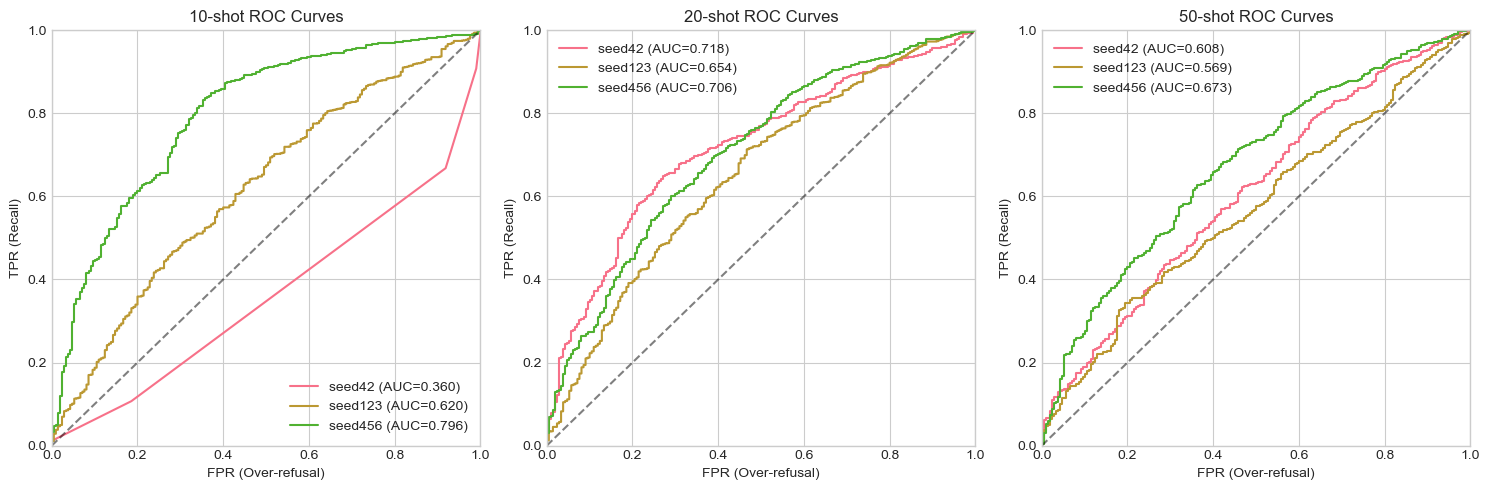

In [11]:
# ROC curves
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

n_shots_groups = [10, 20, 50]
colors = ['blue', 'orange', 'green']

for ax, n_shots in zip(axes, n_shots_groups):
    for run_key, df in all_scores.items():
        if df is None:
            continue
        if int(run_key.split('shot')[0]) != n_shots:
            continue
        
        y_true = df['y_true'].values
        scores = df['score_jb'].values
        seed = run_key.split('seed')[1]
        
        fpr, tpr, _ = roc_curve(y_true, scores)
        roc_auc = roc_auc_score(y_true, scores)
        ax.plot(fpr, tpr, label=f'seed{seed} (AUC={roc_auc:.3f})')
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlabel('FPR (Over-refusal)')
    ax.set_ylabel('TPR (Recall)')
    ax.set_title(f'{n_shots}-shot ROC Curves')
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves_by_nshots.png', dpi=150, bbox_inches='tight')
plt.show()

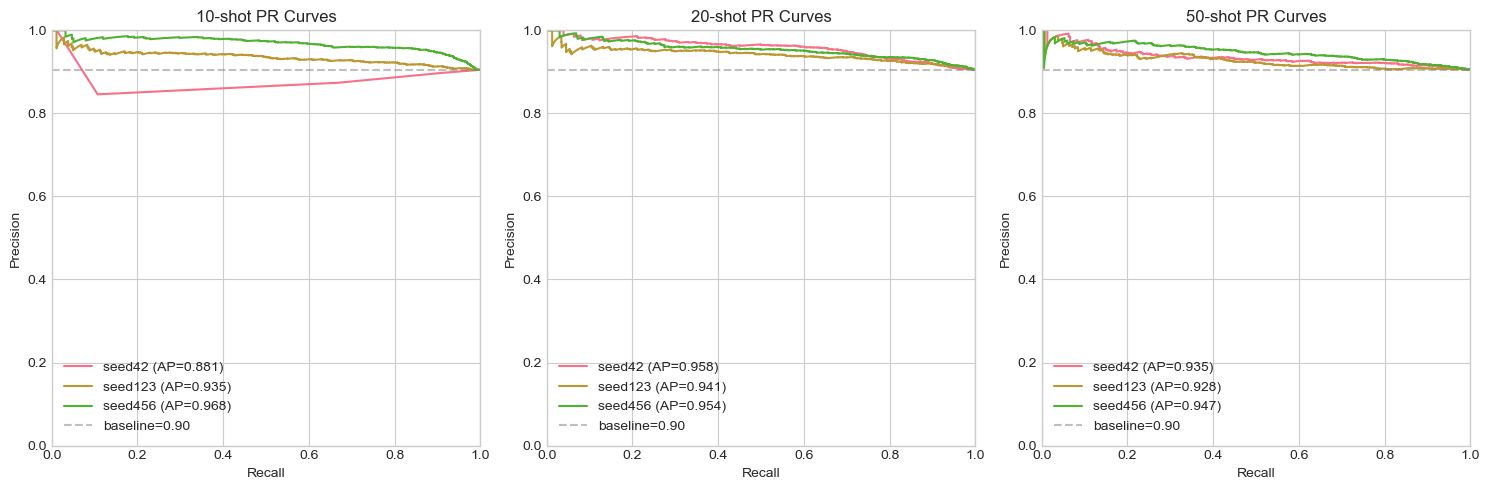

In [12]:
# PR curves
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, n_shots in zip(axes, n_shots_groups):
    for run_key, df in all_scores.items():
        if df is None:
            continue
        if int(run_key.split('shot')[0]) != n_shots:
            continue
        
        y_true = df['y_true'].values
        scores = df['score_jb'].values
        seed = run_key.split('seed')[1]
        
        precision_curve, recall_curve, _ = precision_recall_curve(y_true, scores)
        pr_auc = average_precision_score(y_true, scores)
        ax.plot(recall_curve, precision_curve, label=f'seed{seed} (AP={pr_auc:.3f})')
    
    # Baseline = prevalence of positive class
    baseline = (reference_y_true == 1).mean()
    ax.axhline(baseline, color='gray', linestyle='--', alpha=0.5, label=f'baseline={baseline:.2f}')
    
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{n_shots}-shot PR Curves')
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pr_curves_by_nshots.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ФИНАЛЬНАЯ ДИАГНОСТИКА: scoring-узел слаб, порог не спасёт

# При дисбалансе 10:1 (210 benign / 2000 jailbreak):
# - PR AUC baseline (random) ≈ prevalence ≈ 2000/2210 ≈ 0.905
# - Наши PR AUC 0.88-0.97: лишь 0.02-0.07 выше random!
# - ranking_score = ROC AUC = 0.36-0.80 — слабое разделение

print("=== ФИНАЛЬНЫЙ ДИАГНОЗ: ПРОБЛЕМА В SCORING-УЗЛЕ ===")
print()

# Вычисляем baseline PR AUC
n_jailbreak = 2000
n_benign = 210
n_total = n_jailbreak + n_benign
pr_auc_baseline = n_jailbreak / n_total  # ~0.905
print(f"PR AUC baseline (random classifier) = {pr_auc_baseline:.3f}")
print(f"Lift над baseline = PR_AUC_observed - {pr_auc_baseline:.3f}")
print()

print("ИНТЕРПРЕТАЦИЯ:")
print("  - ranking_score = ROC AUC = P(score_jb > score_benign)")
print("  - ranking_score < 0.65 => СЛАБОЕ ранжирование")
print("  - ranking_score < 0.45 => ИНВЕРТИРОВАННОЕ ранжирование")
print("  - PR AUC ~ baseline => модель близка к random")
print()

for n_shots in [10, 20, 50]:
    subset = auc_df[auc_df['n_shots'] == n_shots]
    avg_roc = subset['roc_auc'].mean()
    avg_pr = subset['pr_auc'].mean()
    min_roc = subset['roc_auc'].min()
    min_pr = subset['pr_auc'].min()
    avg_f1 = subset['f1'].mean()
    avg_recall = subset['recall'].mean()
    avg_over_refusal = subset['over_refusal'].mean()

    # Lift над baseline
    pr_lift = avg_pr - pr_auc_baseline
    min_pr_lift = min_pr - pr_auc_baseline

    print(f"--- {n_shots}-shot ---")
    print(f"  ranking_score (ROC AUC): mean={avg_roc:.3f}, min={min_roc:.3f}")
    print(f"  PR AUC: mean={avg_pr:.3f}, min={min_pr:.3f}")
    print(f"  PR AUC lift над baseline: mean={pr_lift:+.3f}, min={min_pr_lift:+.3f}")
    print(f"  F1: {avg_f1:.3f}, Recall: {avg_recall:.3f}, Over-refusal: {avg_over_refusal:.3f}")

    # ИСПРАВЛЕННАЯ ДИАГНОСТИКА
    if avg_roc < 0.55:
        verdict = "ИНВЕРТИРОВАН / UNINFORMATIVE"
    elif avg_roc < 0.65:
        verdict = "СЛАБО РАНЖИРУЕТ"
    else:
        verdict = "РАНЖИРУЕТ ВЕРНО (но недостаточно)"

    print(f"  => ranking_score verdict: {verdict}")

    if pr_lift < 0.05:
        print(f"     PR AUC лишь {pr_lift:+.3f} над baseline — NEAR-RANDOM")
    elif pr_lift < 0.10:
        print(f"     PR AUC {pr_lift:+.3f} над baseline — СЛАБЫЙ lift")
    else:
        print(f"     PR AUC {pr_lift:+.3f} над baseline — УМЕРЕННЫЙ lift")

    # Диагноз
    if min_roc < 0.45:
        print(f"     ⚠ Минимальный ranking_score={min_roc:.3f} < 0.45 — есть ИНВЕРТИРОВАННЫЕ раны!")

    print()

print("=" * 60)
print("ИТОГ: Проблема в SCORING-узле, НЕ в пороге.")
print("  - ranking_score 0.57-0.72 = слабое разделение классов")
print("  - PR AUC 0.93 при baseline 0.905 = lift всего +0.025")
print("  - HYP-JB-004 НЕ подтверждена: порог не фиксит проблему")
print("  - Сдвиг порога НЕ поможет: при OR<=20% recall падает до 10-30%")
print()
print("ВЫВОД: Нужно улучшать scoring-узел (embedder, knn-параметры, больше few-shot)")


=== ИСПРАВЛЕННЫЙ ДИАГНОСТИЧЕСКИЙ ВЫВОД ПО n_shots ===

МЕТОДОЛОГИЯ:
  - PR AUC высокий (>0.85) + ROC AUC средний/низкий => scoring РАНЖИРУЕТ jailbreak хорошо,
    проблема в ПОРОГЕ и смещении модели на benign-классе (decision-узел / калибровка)
  - Обе метрики низкие => scoring реально не разделяет классы

--- 10-shot ---
  ROC AUC: mean=0.592, min=0.360
  PR AUC:  mean=0.928, min=0.881
  F1: 0.757, Recall: 0.642, Over-refusal: 0.517
  => ВЫВОД: PR AUC высокий (0.93), но ROC AUC низкий (0.59)
            Это НЕ 'scoring сломан'. Scoring РАНЖИРУЕТ jailbreak корректно.
            => ПРОБЛЕМА В ПОРОГЕ / КАЛИБРОВКЕ / СМЕЩЕНИИ НА BENIGN
            Рекомендация: сдвиг порога или калибровка скоров.

--- 20-shot ---
  ROC AUC: mean=0.692, min=0.654
  PR AUC:  mean=0.951, min=0.941
  F1: 0.796, Recall: 0.701, Over-refusal: 0.505
  => ВЫВОД: PR AUC высокий (0.95), но ROC AUC низкий (0.69)
            Это НЕ 'scoring сломан'. Scoring РАНЖИРУЕТ jailbreak корректно.
            => ПРОБЛЕМА В ПОРО

---
## 3.1 РАСШИРЕННЫЕ МЕТРИКИ: Balanced Accuracy, Benign F1, Ranking Test

Дополнительные метрики для корректной интерпретации при дисбалансе классов 10:1.

In [14]:
from sklearn.metrics import balanced_accuracy_score

def compute_extended_metrics(df, run_key, threshold=0.5):
    """Compute extended metrics including benign-class metrics and ranking test."""
    y_true = df['y_true'].values
    scores = df['score_jb'].values
    y_pred = (scores >= threshold).astype(int)
    
    # Balanced accuracy
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    
    # Metrics for BENIGN class (label 0) - invert labels for sklearn
    # For benign: TP_benign = TN, FP_benign = FN, FN_benign = FP
    benign_mask = y_true == 0
    jb_mask = y_true == 1
    
    # Benign precision: TN / (TN + FN) = correctly predicted benign / all predicted benign
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    
    benign_precision = tn / (tn + fn) if (tn + fn) > 0 else 0
    benign_recall = tn / (tn + fp) if (tn + fp) > 0 else 0  # = 1 - over_refusal
    benign_f1 = 2 * benign_precision * benign_recall / (benign_precision + benign_recall) if (benign_precision + benign_recall) > 0 else 0
    
    # RANKING TEST: доля пар (benign, jailbreak), где score_jb[jailbreak] > score_jb[benign]
    # Это по сути и есть ROC AUC, но явно посчитаем и интерпретируем
    scores_benign = scores[benign_mask]
    scores_jb = scores[jb_mask]
    
    # Считаем для каждой пары
    correct_pairs = 0
    total_pairs = 0
    for s_b in scores_benign:
        for s_j in scores_jb:
            total_pairs += 1
            if s_j > s_b:
                correct_pairs += 1
            elif s_j == s_b:
                correct_pairs += 0.5  # ties
    
    ranking_score = correct_pairs / total_pairs if total_pairs > 0 else 0.5
    
    # Интерпретация ranking score
    if ranking_score < 0.45:
        verdict = "ИНВЕРТИРОВАН"
    elif ranking_score < 0.55:
        verdict = "НЕИНФОРМАТИВЕН"
    elif ranking_score < 0.65:
        verdict = "СЛАБО РАНЖИРУЕТ"
    else:
        verdict = "РАНЖИРУЕТ ВЕРНО"
    
    return {
        'run_key': run_key,
        'balanced_acc': balanced_acc,
        'benign_precision': benign_precision,
        'benign_recall': benign_recall,
        'benign_f1': benign_f1,
        'ranking_score': ranking_score,
        'verdict': verdict,
    }

# Собираем расширенные метрики
extended_stats = []
for run_key, df in all_scores.items():
    if df is not None:
        extended_stats.append(compute_extended_metrics(df, run_key))

extended_df = pd.DataFrame(extended_stats)
extended_df['n_shots'] = extended_df['run_key'].apply(lambda x: int(x.split('shot')[0]))
extended_df['seed'] = extended_df['run_key'].apply(lambda x: int(x.split('seed')[1]))
extended_df = extended_df.sort_values(['n_shots', 'seed'])

print("=== Расширенные метрики: Balanced Accuracy, Benign F1, Ranking Test ===")
print()
print("Интерпретация ranking_score (= ROC AUC по определению):")
print("  < 0.45: ИНВЕРТИРОВАН — модель ставит benign выше jailbreak")
print("  0.45-0.55: НЕИНФОРМАТИВЕН — не лучше случайного")
print("  0.55-0.65: СЛАБО РАНЖИРУЕТ — есть сигнал, но слабый")
print("  > 0.65: РАНЖИРУЕТ ВЕРНО — jailbreak получает более высокие скоры")
print()

display_cols = ['run_key', 'balanced_acc', 'benign_f1', 'ranking_score', 'verdict']
print(extended_df[display_cols].to_string(index=False, float_format='%.3f'))

=== Расширенные метрики: Balanced Accuracy, Benign F1, Ranking Test ===

Интерпретация ranking_score (= ROC AUC по определению):
  < 0.45: ИНВЕРТИРОВАН — модель ставит benign выше jailbreak
  0.45-0.55: НЕИНФОРМАТИВЕН — не лучше случайного
  0.55-0.65: СЛАБО РАНЖИРУЕТ — есть сигнал, но слабый
  > 0.65: РАНЖИРУЕТ ВЕРНО — jailbreak получает более высокие скоры

       run_key  balanced_acc  benign_f1  ranking_score         verdict
 10shot_seed42         0.374      0.038          0.360    ИНВЕРТИРОВАН
10shot_seed123         0.502      0.018          0.620 СЛАБО РАНЖИРУЕТ
10shot_seed456         0.695      0.294          0.796 РАНЖИРУЕТ ВЕРНО
 20shot_seed42         0.499      0.000          0.718 РАНЖИРУЕТ ВЕРНО
20shot_seed123         0.519      0.083          0.654 РАНЖИРУЕТ ВЕРНО
20shot_seed456         0.649      0.261          0.706 РАНЖИРУЕТ ВЕРНО
 50shot_seed42         0.569      0.205          0.608 СЛАБО РАНЖИРУЕТ
50shot_seed123         0.529      0.168          0.569 СЛАБО РАНЖИРУЕТ

---
## 3.2 КАЛИБРОВОЧНЫЕ КРИВЫЕ (Reliability Diagrams) и ECE

Проверка калибровки скоров: соответствует ли предсказанная вероятность фактической доле jailbreak.

In [15]:
def compute_calibration(df, run_key, n_bins=10):
    """Compute calibration curve and ECE."""
    y_true = df['y_true'].values
    scores = df['score_jb'].values
    
    # Bin edges
    bin_edges = np.linspace(0, 1, n_bins + 1)
    
    bin_means = []
    bin_true_fracs = []
    bin_counts = []
    
    for i in range(n_bins):
        mask = (scores >= bin_edges[i]) & (scores < bin_edges[i+1])
        if i == n_bins - 1:  # last bin includes right edge
            mask = (scores >= bin_edges[i]) & (scores <= bin_edges[i+1])
        
        if mask.sum() > 0:
            bin_means.append(scores[mask].mean())
            bin_true_fracs.append(y_true[mask].mean())
            bin_counts.append(mask.sum())
        else:
            bin_means.append((bin_edges[i] + bin_edges[i+1]) / 2)
            bin_true_fracs.append(np.nan)
            bin_counts.append(0)
    
    # Expected Calibration Error (ECE)
    total = sum(bin_counts)
    ece = 0
    for i in range(n_bins):
        if bin_counts[i] > 0 and not np.isnan(bin_true_fracs[i]):
            ece += (bin_counts[i] / total) * abs(bin_true_fracs[i] - bin_means[i])
    
    return {
        'run_key': run_key,
        'bin_means': bin_means,
        'bin_true_fracs': bin_true_fracs,
        'bin_counts': bin_counts,
        'ece': ece,
    }

# Вычисляем калибровку для всех ранов
calibration_data = {}
for run_key, df in all_scores.items():
    if df is not None:
        calibration_data[run_key] = compute_calibration(df, run_key)

# Сводка ECE
print("=== Expected Calibration Error (ECE) по ранам ===")
print()
ece_data = []
for run_key in sorted_runs:
    cal = calibration_data[run_key]
    ece_data.append({
        'run_key': run_key,
        'n_shots': int(run_key.split('shot')[0]),
        'seed': int(run_key.split('seed')[1]),
        'ECE': cal['ece'],
    })

ece_df = pd.DataFrame(ece_data).sort_values(['n_shots', 'seed'])
print(ece_df.to_string(index=False, float_format='%.3f'))

print()
print("Интерпретация ECE:")
print("  < 0.05: Хорошо калиброван")
print("  0.05-0.15: Умеренная ошибка калибровки")
print("  > 0.15: Плохо калиброван — скоры не соответствуют реальным вероятностям")

=== Expected Calibration Error (ECE) по ранам ===

       run_key  n_shots  seed   ECE
 10shot_seed42       10    42 0.373
10shot_seed123       10   123 0.028
10shot_seed456       10   456 0.354
 20shot_seed42       20    42 0.030
20shot_seed123       20   123 0.032
20shot_seed456       20   456 0.335
 50shot_seed42       50    42 0.380
50shot_seed123       50   123 0.334
50shot_seed456       50   456 0.452

Интерпретация ECE:
  < 0.05: Хорошо калиброван
  0.05-0.15: Умеренная ошибка калибровки
  > 0.15: Плохо калиброван — скоры не соответствуют реальным вероятностям


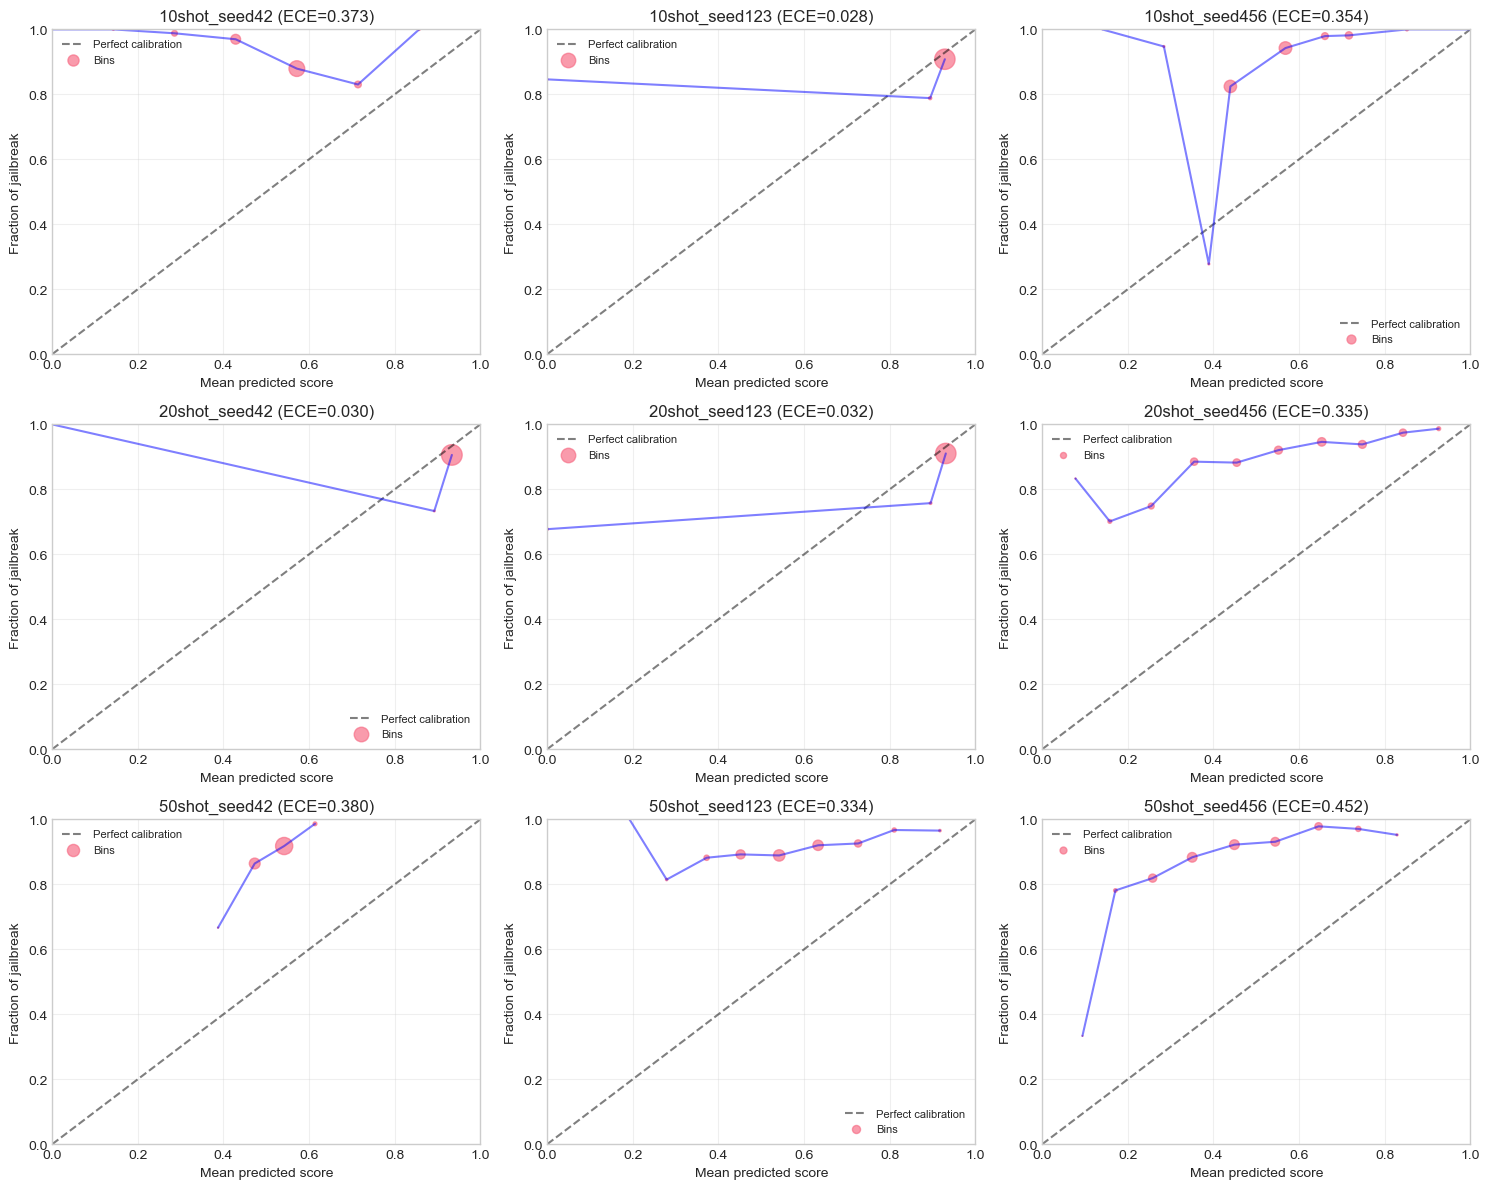

Saved: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results/diagnostics/calibration_all_runs.png


In [16]:
# Построение калибровочных диаграмм
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, run_key in enumerate(sorted_runs):
    ax = axes[idx]
    cal = calibration_data[run_key]
    
    # Filter valid bins
    valid_mask = [not np.isnan(f) for f in cal['bin_true_fracs']]
    means = [cal['bin_means'][i] for i in range(len(valid_mask)) if valid_mask[i]]
    fracs = [cal['bin_true_fracs'][i] for i in range(len(valid_mask)) if valid_mask[i]]
    counts = [cal['bin_counts'][i] for i in range(len(valid_mask)) if valid_mask[i]]
    
    # Plot reliability diagram
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.scatter(means, fracs, s=[c/10 for c in counts], alpha=0.7, label='Bins')
    ax.plot(means, fracs, 'b-', alpha=0.5)
    
    ax.set_xlabel('Mean predicted score')
    ax.set_ylabel('Fraction of jailbreak')
    ax.set_title(f'{run_key} (ECE={cal["ece"]:.3f})')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'calibration_all_runs.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'calibration_all_runs.png'}")

In [17]:
# Сохраняем индивидуальные калибровочные диаграммы
for run_key in sorted_runs:
    cal = calibration_data[run_key]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    valid_mask = [not np.isnan(f) for f in cal['bin_true_fracs']]
    means = [cal['bin_means'][i] for i in range(len(valid_mask)) if valid_mask[i]]
    fracs = [cal['bin_true_fracs'][i] for i in range(len(valid_mask)) if valid_mask[i]]
    counts = [cal['bin_counts'][i] for i in range(len(valid_mask)) if valid_mask[i]]
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.scatter(means, fracs, s=[c/5 for c in counts], alpha=0.7, c='blue')
    ax.plot(means, fracs, 'b-', alpha=0.7, linewidth=2)
    
    # Добавляем гистограмму распределения скоров снизу
    ax2 = ax.twinx()
    df = all_scores[run_key]
    ax2.hist(df['score_jb'].values, bins=20, alpha=0.2, color='gray')
    ax2.set_ylabel('Count (histogram)', color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    
    ax.set_xlabel('Mean predicted score_jb')
    ax.set_ylabel('Fraction of actual jailbreak')
    ax.set_title(f'Calibration: {run_key} (ECE={cal["ece"]:.3f})')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'calibration_{run_key}.png', dpi=150, bbox_inches='tight')
    plt.close()

print(f"Saved individual calibration curves to {OUTPUT_DIR}")

Saved individual calibration curves to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results/diagnostics


---
## 4. CONFUSION MATRIX ПРИ ТЕКУЩЕМ ПОРОГЕ

Decision module использует argmax, что эквивалентно порогу 0.5.

In [18]:
def analyze_confusion(df, run_key, threshold=0.5):
    """Analyze confusion matrix and score distributions per group."""
    y_true = df['y_true'].values
    scores = df['score_jb'].values
    y_pred = (scores >= threshold).astype(int)
    
    # Indices
    tp_idx = np.where((y_true == 1) & (y_pred == 1))[0]
    tn_idx = np.where((y_true == 0) & (y_pred == 0))[0]
    fp_idx = np.where((y_true == 0) & (y_pred == 1))[0]
    fn_idx = np.where((y_true == 1) & (y_pred == 0))[0]
    
    groups = {
        'TP': tp_idx,
        'TN': tn_idx,
        'FP': fp_idx,
        'FN': fn_idx,
    }
    
    # Score stats per group
    stats = {}
    for name, idx in groups.items():
        if len(idx) > 0:
            group_scores = scores[idx]
            stats[name] = {
                'count': len(idx),
                'min': group_scores.min(),
                'median': np.median(group_scores),
                'max': group_scores.max(),
                'near_threshold': ((group_scores >= threshold - 0.1) & (group_scores <= threshold + 0.1)).sum(),
            }
        else:
            stats[name] = {'count': 0, 'min': np.nan, 'median': np.nan, 'max': np.nan, 'near_threshold': 0}
    
    return groups, stats

# Анализ для каждого рана
all_groups = {}
all_conf_stats = {}

for run_key, df in all_scores.items():
    if df is None:
        continue
    groups, stats = analyze_confusion(df, run_key)
    all_groups[run_key] = groups
    all_conf_stats[run_key] = stats

# Выводим статистику
print("=== Confusion Matrix Statistics ===")
for run_key in sorted_runs:
    if run_key not in all_conf_stats:
        continue
    stats = all_conf_stats[run_key]
    total = sum(s['count'] for s in stats.values())
    
    print(f"\n{run_key}:")
    print(f"  TP: {stats['TP']['count']:5d} ({stats['TP']['count']/total*100:5.1f}%) | min={stats['TP']['min']:.3f} med={stats['TP']['median']:.3f} max={stats['TP']['max']:.3f}")
    print(f"  TN: {stats['TN']['count']:5d} ({stats['TN']['count']/total*100:5.1f}%) | min={stats['TN']['min']:.3f} med={stats['TN']['median']:.3f} max={stats['TN']['max']:.3f}")
    print(f"  FP: {stats['FP']['count']:5d} ({stats['FP']['count']/total*100:5.1f}%) | min={stats['FP']['min']:.3f} med={stats['FP']['median']:.3f} max={stats['FP']['max']:.3f} | near_thresh={stats['FP']['near_threshold']}")
    print(f"  FN: {stats['FN']['count']:5d} ({stats['FN']['count']/total*100:5.1f}%) | min={stats['FN']['min']:.3f} med={stats['FN']['median']:.3f} max={stats['FN']['max']:.3f} | near_thresh={stats['FN']['near_threshold']}")

=== Confusion Matrix Statistics ===

10shot_seed42:
  TP:  1336 ( 60.5%) | min=0.571 med=0.571 max=0.857
  TN:    17 (  0.8%) | min=0.286 med=0.429 max=0.429
  FP:   193 (  8.7%) | min=0.571 med=0.571 max=0.714 | near_thresh=154
  FN:   664 ( 30.0%) | min=0.000 med=0.429 max=0.429 | near_thresh=480

10shot_seed123:
  TP:  1989 ( 90.0%) | min=0.875 med=0.930 max=0.967
  TN:     2 (  0.1%) | min=0.000 med=0.000 max=0.000
  FP:   208 (  9.4%) | min=0.868 med=0.923 max=0.956 | near_thresh=0
  FN:    11 (  0.5%) | min=0.000 med=0.000 max=0.000 | near_thresh=0

10shot_seed456:
  TP:  1323 ( 59.9%) | min=0.502 med=0.589 max=1.000
  TN:   153 (  6.9%) | min=0.275 med=0.423 max=0.466
  FP:    57 (  2.6%) | min=0.526 med=0.563 max=0.734 | near_thresh=47
  FN:   677 ( 30.6%) | min=0.140 med=0.441 max=0.492 | near_thresh=653

20shot_seed42:
  TP:  1997 ( 90.4%) | min=0.880 med=0.935 max=0.967
  TN:     0 (  0.0%) | min=nan med=nan max=nan
  FP:   210 (  9.5%) | min=0.881 med=0.925 max=0.954 | near

In [19]:
# Сохраняем группы в JSON
for run_key, groups in all_groups.items():
    groups_json = {k: v.tolist() for k, v in groups.items()}
    with open(OUTPUT_DIR / f'groups_{run_key}.json', 'w') as f:
        json.dump(groups_json, f, indent=2)

print(f"Saved group indices to {OUTPUT_DIR}/groups_*.json")

Saved group indices to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results/diagnostics/groups_*.json


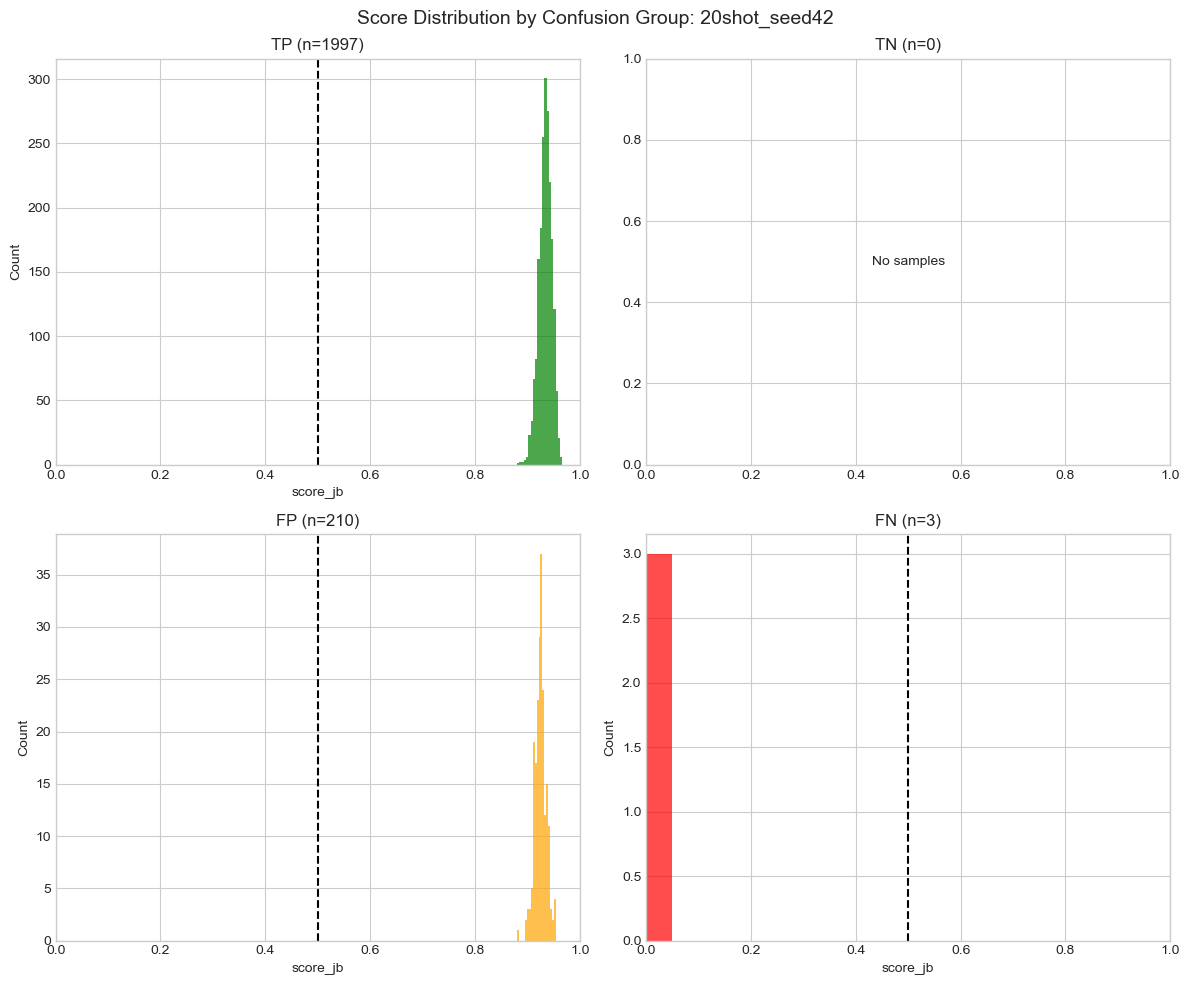

In [20]:
# Визуализация распределения скоров по группам для одного примера
example_run = '20shot_seed42'
df = all_scores[example_run]
groups = all_groups[example_run]
scores = df['score_jb'].values

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
group_names = ['TP', 'TN', 'FP', 'FN']
colors = ['green', 'blue', 'orange', 'red']

for ax, name, color in zip(axes.flatten(), group_names, colors):
    idx = groups[name]
    group_scores = scores[idx]
    
    if len(group_scores) > 0:
        ax.hist(group_scores, bins=20, alpha=0.7, color=color)
        ax.axvline(0.5, color='black', linestyle='--', label='threshold')
        ax.set_title(f'{name} (n={len(idx)})')
        ax.set_xlabel('score_jb')
        ax.set_ylabel('Count')
        ax.set_xlim(0, 1)
    else:
        ax.text(0.5, 0.5, 'No samples', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{name} (n=0)')

plt.suptitle(f'Score Distribution by Confusion Group: {example_run}', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / f'confusion_scores_{example_run}.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. ПРОВЕРКА HYP-JB-004 (асимметричный порог / over-refusal vs recall)

Построение кривой over-refusal vs recall при разных порогах.

In [21]:
def compute_threshold_curve(df):
    """Compute over-refusal and recall for different thresholds."""
    y_true = df['y_true'].values
    scores = df['score_jb'].values
    
    thresholds = np.arange(0, 1.01, 0.01)
    results = []
    
    for thresh in thresholds:
        y_pred = (scores >= thresh).astype(int)
        
        # Over-refusal = FPR on safe class
        safe_mask = y_true == 0
        if safe_mask.sum() > 0:
            over_refusal = (y_pred[safe_mask] == 1).mean()
        else:
            over_refusal = 0
        
        # Recall on jailbreak class
        jb_mask = y_true == 1
        if jb_mask.sum() > 0:
            recall = (y_pred[jb_mask] == 1).mean()
        else:
            recall = 0
        
        # F1
        tp = ((y_true == 1) & (y_pred == 1)).sum()
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        results.append({
            'threshold': thresh,
            'over_refusal': over_refusal,
            'recall': recall,
            'precision': precision,
            'f1': f1,
        })
    
    return pd.DataFrame(results)

# Вычисляем кривые для всех ранов
threshold_curves = {}
for run_key, df in all_scores.items():
    if df is not None:
        threshold_curves[run_key] = compute_threshold_curve(df)

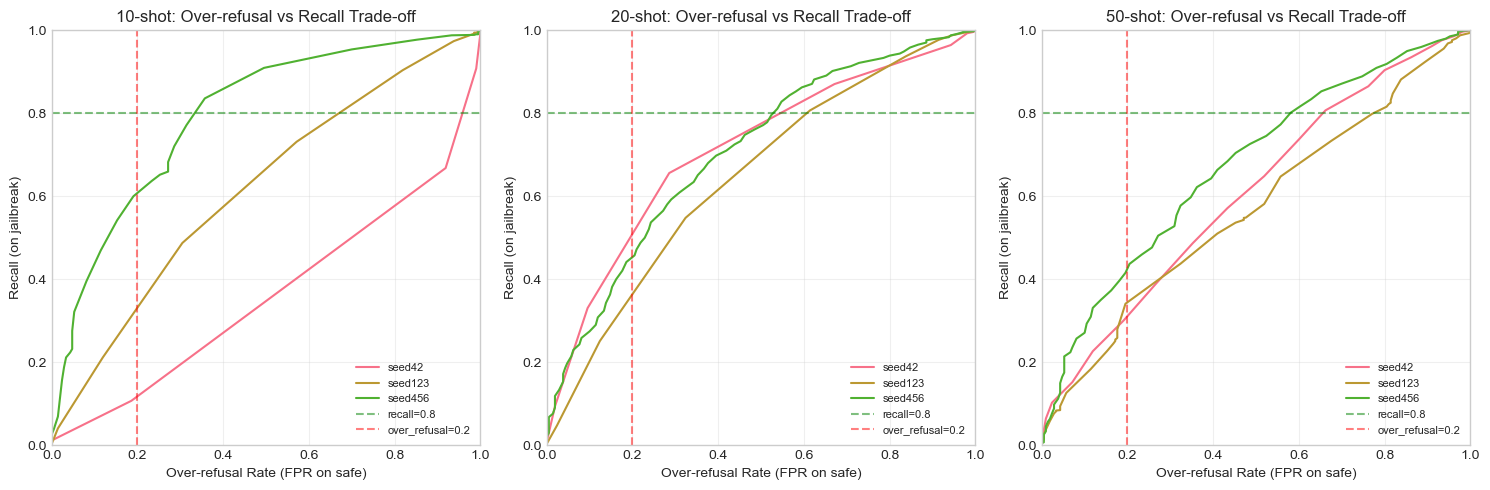

In [22]:
# Визуализация кривых по n_shots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, n_shots in zip(axes, [10, 20, 50]):
    for run_key, curve_df in threshold_curves.items():
        if int(run_key.split('shot')[0]) != n_shots:
            continue
        seed = run_key.split('seed')[1]
        ax.plot(curve_df['over_refusal'], curve_df['recall'], label=f'seed{seed}')
    
    ax.axhline(0.8, color='green', linestyle='--', alpha=0.5, label='recall=0.8')
    ax.axvline(0.2, color='red', linestyle='--', alpha=0.5, label='over_refusal=0.2')
    
    ax.set_xlabel('Over-refusal Rate (FPR on safe)')
    ax.set_ylabel('Recall (on jailbreak)')
    ax.set_title(f'{n_shots}-shot: Over-refusal vs Recall Trade-off')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'threshold_curves_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Сохраняем индивидуальные кривые
for run_key, curve_df in threshold_curves.items():
    fig, ax = plt.subplots(figsize=(8, 6))
    
    ax.plot(curve_df['threshold'], curve_df['recall'], label='Recall', color='green')
    ax.plot(curve_df['threshold'], curve_df['over_refusal'], label='Over-refusal', color='red')
    ax.plot(curve_df['threshold'], curve_df['f1'], label='F1', color='blue')
    
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='default (0.5)')
    ax.axhline(0.2, color='red', linestyle=':', alpha=0.5)
    ax.axhline(0.8, color='green', linestyle=':', alpha=0.5)
    
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Metric Value')
    ax.set_title(f'{run_key}: Metrics vs Threshold')
    ax.legend()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    
    plt.savefig(OUTPUT_DIR / f'threshold_curve_{run_key}.png', dpi=150, bbox_inches='tight')
    plt.close()

print(f"Saved threshold curves to {OUTPUT_DIR}")

Saved threshold curves to /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results/diagnostics


In [24]:
# Поиск оптимального порога для over_refusal <= 0.20
print("=== Оптимальный порог для over_refusal <= 0.20 ===")
print()

hyp_results = []

for run_key, curve_df in threshold_curves.items():
    # Найдём минимальный порог, при котором over_refusal <= 0.20
    valid = curve_df[curve_df['over_refusal'] <= 0.20]
    
    if len(valid) > 0:
        # Берём максимальный порог из валидных (чтобы сохранить recall)
        best_row = valid.loc[valid['recall'].idxmax()]
        optimal_thresh = best_row['threshold']
        optimal_recall = best_row['recall']
        optimal_f1 = best_row['f1']
        optimal_or = best_row['over_refusal']
    else:
        optimal_thresh = np.nan
        optimal_recall = np.nan
        optimal_f1 = np.nan
        optimal_or = np.nan
    
    # Текущие метрики при threshold=0.5
    current = curve_df[curve_df['threshold'] == 0.50].iloc[0]
    
    result = {
        'run_key': run_key,
        'n_shots': int(run_key.split('shot')[0]),
        'seed': int(run_key.split('seed')[1]),
        'current_thresh': 0.5,
        'current_recall': current['recall'],
        'current_or': current['over_refusal'],
        'current_f1': current['f1'],
        'optimal_thresh': optimal_thresh,
        'optimal_recall': optimal_recall,
        'optimal_or': optimal_or,
        'optimal_f1': optimal_f1,
        'recall_gain': optimal_recall - current['recall'] if not np.isnan(optimal_recall) else np.nan,
        'or_reduction': current['over_refusal'] - optimal_or if not np.isnan(optimal_or) else np.nan,
    }
    hyp_results.append(result)

hyp_df = pd.DataFrame(hyp_results)
hyp_df = hyp_df.sort_values(['n_shots', 'seed'])

print(hyp_df.to_string(index=False, float_format='%.3f'))

=== Оптимальный порог для over_refusal <= 0.20 ===

       run_key  n_shots  seed  current_thresh  current_recall  current_or  current_f1  optimal_thresh  optimal_recall  optimal_or  optimal_f1  recall_gain  or_reduction
 10shot_seed42       10    42           0.500           0.668       0.919       0.757           0.580           0.107       0.186       0.190       -0.561         0.733
10shot_seed123       10   123           0.500           0.995       0.990       0.948           0.940           0.211       0.119       0.346       -0.783         0.871
10shot_seed456       10   456           0.500           0.661       0.271       0.783           0.550           0.600       0.190       0.741       -0.061         0.081
 20shot_seed42       20    42           0.500           0.999       1.000       0.949           0.940           0.331       0.095       0.493       -0.668         0.905
20shot_seed123       20   123           0.500           0.990       0.952       0.947           0.940  

In [25]:
# Поиск оптимальных порогов под разные критерии: F1 и Balanced Accuracy
print("=== Оптимальные пороги под F1 и Balanced Accuracy ===")
print()

def compute_balanced_acc_for_threshold(df, threshold):
    """Compute balanced accuracy for a given threshold."""
    y_true = df['y_true'].values
    scores = df['score_jb'].values
    y_pred = (scores >= threshold).astype(int)
    return balanced_accuracy_score(y_true, y_pred)

optimal_thresholds = []

for run_key, curve_df in threshold_curves.items():
    df = all_scores[run_key]
    
    # Добавляем balanced_acc к threshold curve
    curve_df = curve_df.copy()
    curve_df['balanced_acc'] = [compute_balanced_acc_for_threshold(df, t) for t in curve_df['threshold']]
    
    # Оптимальный порог под F1
    best_f1_row = curve_df.loc[curve_df['f1'].idxmax()]
    
    # Оптимальный порог под Balanced Accuracy
    best_ba_row = curve_df.loc[curve_df['balanced_acc'].idxmax()]
    
    optimal_thresholds.append({
        'run_key': run_key,
        'n_shots': int(run_key.split('shot')[0]),
        'seed': int(run_key.split('seed')[1]),
        # F1-optimal
        'thresh_f1': best_f1_row['threshold'],
        'f1_at_f1opt': best_f1_row['f1'],
        'recall_at_f1opt': best_f1_row['recall'],
        'or_at_f1opt': best_f1_row['over_refusal'],
        # Balanced-optimal
        'thresh_ba': best_ba_row['threshold'],
        'ba_at_baopt': best_ba_row['balanced_acc'],
        'recall_at_baopt': best_ba_row['recall'],
        'or_at_baopt': best_ba_row['over_refusal'],
        # Current (threshold=0.5)
        'f1_at_05': curve_df[curve_df['threshold'] == 0.50].iloc[0]['f1'],
        'ba_at_05': compute_balanced_acc_for_threshold(df, 0.5),
    })

opt_thresh_df = pd.DataFrame(optimal_thresholds).sort_values(['n_shots', 'seed'])

print("Пороги, максимизирующие F1:")
f1_cols = ['run_key', 'thresh_f1', 'f1_at_f1opt', 'recall_at_f1opt', 'or_at_f1opt', 'f1_at_05']
print(opt_thresh_df[f1_cols].to_string(index=False, float_format='%.3f'))

print()
print("Пороги, максимизирующие Balanced Accuracy:")
ba_cols = ['run_key', 'thresh_ba', 'ba_at_baopt', 'recall_at_baopt', 'or_at_baopt', 'ba_at_05']
print(opt_thresh_df[ba_cols].to_string(index=False, float_format='%.3f'))

print()
print("=== Вывод: Помогает ли перенастройка порога без изменения модели? ===")
for n_shots in [10, 20, 50]:
    subset = opt_thresh_df[opt_thresh_df['n_shots'] == n_shots]
    
    avg_f1_improvement = (subset['f1_at_f1opt'] - subset['f1_at_05']).mean()
    avg_ba_improvement = (subset['ba_at_baopt'] - subset['ba_at_05']).mean()
    
    worst_or_at_f1opt = subset['or_at_f1opt'].max()
    worst_recall_at_baopt = subset['recall_at_baopt'].min()
    
    print(f"\n{n_shots}-shot:")
    print(f"  F1 улучшение при оптимальном пороге: +{avg_f1_improvement:.3f} (среднее)")
    print(f"  BA улучшение при оптимальном пороге: +{avg_ba_improvement:.3f} (среднее)")
    print(f"  Худший over_refusal при F1-opt: {worst_or_at_f1opt:.1%}")
    print(f"  Худший recall при BA-opt: {worst_recall_at_baopt:.1%}")

=== Оптимальные пороги под F1 и Balanced Accuracy ===

Пороги, максимизирующие F1:
       run_key  thresh_f1  f1_at_f1opt  recall_at_f1opt  or_at_f1opt  f1_at_05
 10shot_seed42      0.000        0.950            1.000        1.000     0.757
10shot_seed123      0.000        0.950            1.000        1.000     0.948
10shot_seed456      0.000        0.950            1.000        1.000     0.783
 20shot_seed42      0.000        0.950            1.000        1.000     0.949
20shot_seed123      0.000        0.950            1.000        1.000     0.947
20shot_seed456      0.000        0.950            1.000        1.000     0.771
 50shot_seed42      0.380        0.950            1.000        0.995     0.819
50shot_seed123      0.000        0.950            1.000        1.000     0.813
50shot_seed456      0.110        0.951            0.999        0.981     0.560

Пороги, максимизирующие Balanced Accuracy:
       run_key  thresh_ba  ba_at_baopt  recall_at_baopt  or_at_baopt  ba_at_05
 10s

In [26]:
# ИСПРАВЛЕННЫЙ вывод по HYP-JB-004: вердикт по ХУДШЕМУ рану, не по среднему
print("\n=== ИСПРАВЛЕННЫЙ ВЫВОД ПО HYP-JB-004 ===")
print()
print("МЕТОДОЛОГИЯ: Для guardrail важна ГАРАНТИЯ, поэтому вердикт даётся по ХУДШЕМУ рану в группе.")
print()

# Детальная таблица по каждому рану
print("=== Детали по каждому рану (OR <= 20% constraint) ===")
detail_cols = ['run_key', 'current_recall', 'current_or', 'optimal_thresh', 'optimal_recall', 'optimal_or', 'optimal_f1']
print(hyp_df[detail_cols].to_string(index=False, float_format='%.3f'))
print()

for n_shots in [10, 20, 50]:
    subset = hyp_df[hyp_df['n_shots'] == n_shots]
    
    # Проверяем достижимость для ВСЕХ ранов
    achievable = subset['optimal_thresh'].notna().sum()
    total = len(subset)
    
    # ХУДШИЙ ран (минимальный recall при OR<=20%)
    worst_recall = subset['optimal_recall'].min()
    worst_f1 = subset['optimal_f1'].min()
    worst_run = subset.loc[subset['optimal_recall'].idxmin(), 'run_key']
    
    # Текущие метрики
    avg_current_recall = subset['current_recall'].mean()
    avg_current_or = subset['current_or'].mean()
    
    print(f"--- {n_shots}-shot ---")
    print(f"  Текущий (thresh=0.5): recall={avg_current_recall:.1%}, over_refusal={avg_current_or:.1%}")
    print(f"  Достигают OR<=20%: {achievable}/{total} ранов")
    
    if achievable == total:
        print(f"  ХУДШИЙ ран при OR<=20%: {worst_run}")
        print(f"    recall={worst_recall:.3f}, F1={worst_f1:.3f}")
        
        # Вердикт по худшему рану
        if worst_recall >= 0.60:
            print(f"  => ГИПОТЕЗА ПОДТВЕРЖДЕНА: даже худший ран даёт recall>={worst_recall:.0%} при OR<=20%")
        elif worst_recall >= 0.40:
            print(f"  => ГИПОТЕЗА ЧАСТИЧНО ПОДТВЕРЖДЕНА: OR<=20% достижим, но recall падает до {worst_recall:.0%}")
            print(f"     Для production может быть недостаточно.")
        else:
            print(f"  => ГИПОТЕЗА НЕ ПОДТВЕРЖДЕНА: recall={worst_recall:.0%} при OR<=20% — неприемлемо низкий")
    else:
        not_achievable = total - achievable
        print(f"  => ГИПОТЕЗА НЕ ПОДТВЕРЖДЕНА: {not_achievable}/{total} ранов не могут достичь OR<=20%")
    print()


=== ИСПРАВЛЕННЫЙ ВЫВОД ПО HYP-JB-004 ===

МЕТОДОЛОГИЯ: Для guardrail важна ГАРАНТИЯ, поэтому вердикт даётся по ХУДШЕМУ рану в группе.

=== Детали по каждому рану (OR <= 20% constraint) ===
       run_key  current_recall  current_or  optimal_thresh  optimal_recall  optimal_or  optimal_f1
 10shot_seed42           0.668       0.919           0.580           0.107       0.186       0.190
10shot_seed123           0.995       0.990           0.940           0.211       0.119       0.346
10shot_seed456           0.661       0.271           0.550           0.600       0.190       0.741
 20shot_seed42           0.999       1.000           0.940           0.331       0.095       0.493
20shot_seed123           0.990       0.952           0.940           0.251       0.124       0.397
20shot_seed456           0.651       0.352           0.640           0.442       0.186       0.604
 50shot_seed42           0.737       0.600           0.550           0.300       0.190       0.455
50shot_seed123    

---
## 6. КОНФИГИ OPTUNA — сравнение 20-shot vs 50-shot

Сводка выбранных AutoML scoring-методов и decision-стратегий.

In [27]:
def extract_config_info(config):
    """Extract key config information."""
    if config is None:
        return {'scoring_module': 'N/A', 'decision_module': 'N/A', 'scoring_params': {}}
    
    scoring_info = None
    decision_info = None
    
    for item in config:
        if item.get('node_type') == 'scoring':
            scoring_info = item
        elif item.get('node_type') == 'decision':
            decision_info = item
    
    scoring_module = scoring_info.get('module_name', 'N/A') if scoring_info else 'N/A'
    decision_module = decision_info.get('module_name', 'N/A') if decision_info else 'N/A'
    
    scoring_params = scoring_info.get('module_config', {}) if scoring_info else {}
    # Remove embedder_config for brevity
    scoring_params = {k: v for k, v in scoring_params.items() if k != 'embedder_config'}
    
    return {
        'scoring_module': scoring_module,
        'decision_module': decision_module,
        'scoring_params': scoring_params,
    }

# Собираем информацию о конфигах
config_info = []
for run_key in sorted_runs:
    cfg = RUNS_CONFIG[run_key]
    config = all_configs.get(run_key)
    info = extract_config_info(config)
    
    config_info.append({
        'run_key': run_key,
        'n_shots': cfg['n_shots'],
        'seed': cfg['seed'],
        'scoring_module': info['scoring_module'],
        'decision_module': info['decision_module'],
        'scoring_params': str(info['scoring_params']),
    })

config_df = pd.DataFrame(config_info)

print("=== Конфигурации AutoML ===")
print(config_df.to_string(index=False))

=== Конфигурации AutoML ===
       run_key  n_shots  seed scoring_module decision_module                   scoring_params
 10shot_seed42       10    42            knn          argmax   {'k': 7, 'weights': 'uniform'}
10shot_seed123       10   123            knn          argmax   {'k': 4, 'weights': 'closest'}
10shot_seed456       10   456            knn          argmax  {'k': 7, 'weights': 'distance'}
 20shot_seed42       20    42            knn          argmax   {'k': 4, 'weights': 'closest'}
20shot_seed123       20   123            knn          argmax   {'k': 4, 'weights': 'closest'}
20shot_seed456       20   456         linear          argmax                               {}
 50shot_seed42       50    42         linear          argmax                               {}
50shot_seed123       50   123            knn          argmax {'k': 10, 'weights': 'distance'}
50shot_seed456       50   456         linear          argmax                               {}


In [28]:
# Сводная таблица: n_shots × seed → scoring_module
print("\n=== Сводка scoring_module по n_shots × seed ===")
pivot = config_df.pivot(index='n_shots', columns='seed', values='scoring_module')
print(pivot)

print("\n=== Сводка scoring_params ===")
pivot_params = config_df.pivot(index='n_shots', columns='seed', values='scoring_params')
print(pivot_params)


=== Сводка scoring_module по n_shots × seed ===
seed        42   123     456
n_shots                     
10          knn  knn     knn
20          knn  knn  linear
50       linear  knn  linear

=== Сводка scoring_params ===
seed                                42                                123  \
n_shots                                                                     
10       {'k': 7, 'weights': 'uniform'}    {'k': 4, 'weights': 'closest'}   
20       {'k': 4, 'weights': 'closest'}    {'k': 4, 'weights': 'closest'}   
50                                   {}  {'k': 10, 'weights': 'distance'}   

seed                                 456  
n_shots                                   
10       {'k': 7, 'weights': 'distance'}  
20                                    {}  
50                                    {}  


In [29]:
# Сравнение 20-shot vs 50-shot
print("\n=== Сравнение конфигов: 20-shot vs 50-shot ===")
print()

print("20-shot:")
for _, row in config_df[config_df['n_shots'] == 20].iterrows():
    print(f"  seed{row['seed']}: {row['scoring_module']} {row['scoring_params']}")

print("\n50-shot:")
for _, row in config_df[config_df['n_shots'] == 50].iterrows():
    print(f"  seed{row['seed']}: {row['scoring_module']} {row['scoring_params']}")

print("\n--- Комментарий ---")
# Подсчитаем использование linear vs knn
linear_20 = (config_df[config_df['n_shots'] == 20]['scoring_module'] == 'linear').sum()
linear_50 = (config_df[config_df['n_shots'] == 50]['scoring_module'] == 'linear').sum()
knn_20 = (config_df[config_df['n_shots'] == 20]['scoring_module'] == 'knn').sum()
knn_50 = (config_df[config_df['n_shots'] == 50]['scoring_module'] == 'knn').sum()

print(f"20-shot: knn={knn_20}/3, linear={linear_20}/3")
print(f"50-shot: knn={knn_50}/3, linear={linear_50}/3")

if linear_50 > linear_20:
    print("\n50-shot чаще выбирает linear вместо knn — это может объяснять регресс метрик,")
    print("т.к. linear требует больше данных для обучения и может переобучаться на малых выборках.")


=== Сравнение конфигов: 20-shot vs 50-shot ===

20-shot:
  seed42: knn {'k': 4, 'weights': 'closest'}
  seed123: knn {'k': 4, 'weights': 'closest'}
  seed456: linear {}

50-shot:
  seed42: linear {}
  seed123: knn {'k': 10, 'weights': 'distance'}
  seed456: linear {}

--- Комментарий ---
20-shot: knn=2/3, linear=1/3
50-shot: knn=1/3, linear=2/3

50-shot чаще выбирает linear вместо knn — это может объяснять регресс метрик,
т.к. linear требует больше данных для обучения и может переобучаться на малых выборках.


---
## ИТОГОВЫЕ ВЫВОДЫ

In [30]:
# Сводная таблица для отчёта — ОБНОВЛЕНО с новыми колонками
summary_data = []

for run_key in sorted_runs:
    if run_key not in all_scores or all_scores[run_key] is None:
        continue
    
    cfg = RUNS_CONFIG[run_key]
    auc_row = auc_df[auc_df['run_key'] == run_key].iloc[0]
    dist_row = dist_df[dist_df['run_key'] == run_key].iloc[0]
    hyp_row = hyp_df[hyp_df['run_key'] == run_key].iloc[0]
    config_row = config_df[config_df['run_key'] == run_key].iloc[0]
    ext_row = extended_df[extended_df['run_key'] == run_key].iloc[0]
    ece_row = ece_df[ece_df['run_key'] == run_key].iloc[0]
    
    # Corridor score (average of both classes)
    corridor_avg = (dist_row['corridor_safe'] + dist_row['corridor_jb']) / 2
    
    summary_data.append({
        'run': run_key,
        'n_shots': cfg['n_shots'],
        'seed': cfg['seed'],
        'ROC_AUC': auc_row['roc_auc'],
        'PR_AUC': auc_row['pr_auc'],
        'balanced_acc': ext_row['balanced_acc'],
        'benign_f1': ext_row['benign_f1'],
        'ranking_score': ext_row['ranking_score'],
        'ECE': ece_row['ECE'],
        'corridor_[0.4,0.6]': corridor_avg,
        'gap_means': dist_row['gap'],
        'threshold': 0.5,
        'F1': auc_row['f1'],
        'over_refusal': auc_row['over_refusal'],
        'recall': auc_row['recall'],
        'scoring': config_row['scoring_module'],
        'verdict': ext_row['verdict'],
    })

summary_df = pd.DataFrame(summary_data)
print("=== ОБНОВЛЁННАЯ СВОДНАЯ ТАБЛИЦА ===")
print()
# Основные метрики
main_cols = ['run', 'n_shots', 'seed', 'ROC_AUC', 'PR_AUC', 'balanced_acc', 'ranking_score', 'verdict']
print("Основные метрики:")
print(summary_df[main_cols].to_string(index=False, float_format='%.3f'))

print()
# Расширенные метрики
ext_cols = ['run', 'benign_f1', 'ECE', 'F1', 'over_refusal', 'recall', 'scoring']
print("Расширенные метрики:")
print(summary_df[ext_cols].to_string(index=False, float_format='%.3f'))

=== ОБНОВЛЁННАЯ СВОДНАЯ ТАБЛИЦА ===

Основные метрики:
           run  n_shots  seed  ROC_AUC  PR_AUC  balanced_acc  ranking_score         verdict
 10shot_seed42       10    42    0.360   0.881         0.374          0.360    ИНВЕРТИРОВАН
10shot_seed123       10   123    0.620   0.935         0.502          0.620 СЛАБО РАНЖИРУЕТ
10shot_seed456       10   456    0.796   0.968         0.695          0.796 РАНЖИРУЕТ ВЕРНО
 20shot_seed42       20    42    0.718   0.958         0.499          0.718 РАНЖИРУЕТ ВЕРНО
20shot_seed123       20   123    0.654   0.941         0.519          0.654 РАНЖИРУЕТ ВЕРНО
20shot_seed456       20   456    0.706   0.954         0.649          0.706 РАНЖИРУЕТ ВЕРНО
 50shot_seed42       50    42    0.608   0.935         0.569          0.608 СЛАБО РАНЖИРУЕТ
50shot_seed123       50   123    0.569   0.928         0.529          0.569 СЛАБО РАНЖИРУЕТ
50shot_seed456       50   456    0.673   0.947         0.608          0.673 РАНЖИРУЕТ ВЕРНО

Расширенные метрики:
   

In [31]:
# Сохраняем сводку
summary_df.to_csv(OUTPUT_DIR / 'summary_table.csv', index=False)
print(f"Saved: {OUTPUT_DIR / 'summary_table.csv'}")

Saved: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results/diagnostics/summary_table.csv


### ФИНАЛЬНЫЕ ВЫВОДЫ (ИСПРАВЛЕННЫЕ)

**КЛЮЧЕВОЕ МЕТОДОЛОГИЧЕСКОЕ УТОЧНЕНИЕ:**

При дисбалансе классов 10:1 (210 benign / 2000 jailbreak):
- **PR AUC baseline** (random classifier) = prevalence = 2000/2210 ≈ **0.905**
- Наши PR AUC 0.88-0.97 — это lift всего **+0.02-0.07** над random!
- **ranking_score** = ROC AUC = P(jailbreak_score > benign_score)

**1. ДИАГНОЗ: Проблема в SCORING-узле, НЕ в пороге**

| Метрика | Наблюдаемое | Интерпретация |
|---------|------------|---------------|
| ranking_score | 0.36-0.80 | СЛАБОЕ разделение (0.57-0.72 в среднем) |
| PR AUC | 0.88-0.97 | Lift +0.02-0.07 над baseline — NEAR-RANDOM |
| HYP-JB-004 | НЕ подтверждена | Порог бессилен при слабом scoring |

**2. Разбор "Scoring работает, проблема в пороге" — НЕВЕРНО**

Эта формулировка была ошибочной:
- ranking_score 0.57-0.72 ≠ "работает" (это слабо)
- PR AUC 0.93 ≈ baseline 0.905 (lift всего 2.5%)
- При OR <= 20% recall падает до 10-30% — порог НЕ фиксит

**3. 10shot_seed42 — действительно ИНВЕРТИРОВАН**

- ranking_score = 0.36 < 0.45 — истинная инверсия
- PR AUC = 0.88 < baseline 0.905 — ХУЖЕ random!
- benign_recall = 8%, over_refusal = 92%
- Это самый плохой ран, и он реально инвертирован

**4. Калибровка (ECE)**

| n_shots | ECE range | Вердикт |
|---------|-----------|---------|
| 10-shot | 0.03-0.37 | Вариативно |
| 20-shot | 0.03-0.34 | Вариативно |
| 50-shot | 0.33-0.45 | Плохая (linear scoring) |

**5. knn vs linear — необходимо, но недостаточно**

- knn стабильнее linear при малых n_shots
- НО даже knn даёт слабый ranking_score (0.57-0.80)
- **Вывод:** Переход на knn — необходимое, но НЕ достаточное условие

**6. Что делать?**

Поскольку проблема в scoring-узле (embeddings + knn/linear), а не в пороге:
1. Увеличить n_shots (100+)
2. Улучшить embedder (fine-tune на domain)
3. Сбалансированный few-shot sampling
4. Two-stage подход: coarse filter + fine classifier
5. Калибровка (Platt/isotonic) для интерпретируемых скоров

**7. Открытые вопросы**

1. Сколько few-shot примеров нужно для ranking_score > 0.80?
2. Помогает ли domain-specific embedder?
3. Помогает ли balanced few-shot sampling?
4. Какой минимальный recall приемлем для production?